## 数据探索

In [1]:
import pandas as pd
# 读取训练样本和测试样本
data_train = pd.read_csv('../data/train.csv')
data_test = pd.read_csv('../data/test.csv')

# 对数据进行描述性统计分析
# 返回缺失值个数、最大值、最小值
# 训练样本的描述性统计分析
# 在describe函数中，percentiles参数表示指定计算的分位数表，如1/4分位数、中位数等
explore_train = data_train.describe(percentiles=[], include='all').T
explore_train['null'] = data_train.isnull().sum()  # 计算缺失值
explore_train = explore_train[['null', 'max', 'min']]
explore_train.columns = ['空值数', '最大值', '最小值']  # 表头重命名

# 测试样本的描述性统计分析
explore_test = data_test.describe(percentiles=[], include='all').T
explore_test['null'] = data_test.isnull().sum()  # 统计缺失值
explore_test = explore_test[['null', 'max', 'min']]
explore_test.columns = ['空值数', '最大值', '最小值']  # 表头重命名

# 写出结果
explore_train.to_csv('../tmp/explore_train.csv')  # 训练样本的描述性统计分析
print('训练样本的描述性统计分析：\n', explore_train)
print()
explore_test.to_csv('../tmp/explore_test.csv')  # 测试样本的描述性统计分析
print('测试样本的描述性统计分析：\n', explore_test)

# 合并训练数据和测试数据
data1 = pd.concat([data_train, data_test], axis=0)
# 处理data_received属性、date属性
data1['date_received'] = data1['date_received'].astype('str').apply(lambda x: x.split('.')[0])
data1['date_received'] = pd.to_datetime(data1['date_received'])
data1['date'] = data1[ 'date'].astype('str').apply(lambda x: x.split('.')[0])
data1['date'] = pd.to_datetime(data1['date'])


D:\DELL\AppData\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3063: DtypeWarning: Columns (3) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


训练样本的描述性统计分析：
                   空值数          最大值          最小值
user_id             0  7.36103e+06            4
merchant_id         0         8856            1
coupon_id      578569        14045            1
discount_rate  578569          NaN          NaN
distance            0           10            0
date_received  578569  2.01605e+07  2.01601e+07
date           804951  2.01606e+07  2.01601e+07

测试样本的描述性统计分析：
                   空值数          最大值          最小值
user_id             0  7.36097e+06            4
merchant_id         0         8856            1
coupon_id      123033        14045            1
discount_rate  123033          NaN          NaN
distance            0           10            0
date_received  123033  2.01606e+07  2.01606e+07
date            75163  2.01606e+07  2.01606e+07


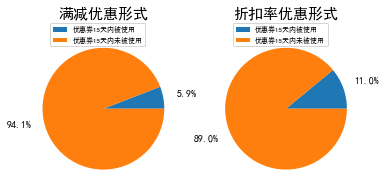

In [2]:
# 绘制图形分析满减优惠和形式和折扣率优惠形式
import matplotlib.pyplot as plt
import re

indexOne = data1['discount_rate'].astype(str).apply(lambda x: re.findall('\d+:\d+', x) != [])  # 满减优惠形式的索引
indexTwo = data1['discount_rate'].astype(str).apply(lambda x: re.findall('\d+\.\d+', x) != [])  # 折扣率优惠形式的索引
dfOne = data1.loc[indexOne, :]  # 取出满减优惠形式的数据
dfTwo = data1.loc[indexTwo, :]  # 取出折扣率优惠形式的数据
# 在满减优惠形式的数据中，15天内优惠券被使用的数目
numberOne = sum((dfOne['date'] - dfOne['date_received']).dt.days <= 15)
# 在满减优惠形式的数据中，15天内优惠券未被使用的数目
numberTwo = len(dfOne) - numberOne
# 在折扣率优惠形式的数据中，15天内优惠券被使用的数目
numberThree = sum((dfTwo['date'] - dfTwo['date_received']).dt.days <= 15)
# 在折扣率优惠形式的数据中，15天内优惠券未被使用的数目
numberFour = len(dfTwo) - numberThree
# 绘制图形
plt.figure(figsize=(6, 3))
plt.rcParams['font.sans-serif'] = 'Simhei'
plt.subplot(1, 2, 1)
plt.pie([numberOne, numberTwo], autopct='%.1f%%', pctdistance=1.4)
plt.legend(['优惠券15天内被使用', '优惠券15天内未被使用'], fontsize=7, loc=(0.15, 0.91))  # 添加图例
plt.title('满减优惠形式', fontsize=15, y=1.05)  # 添加标题
plt.subplot(1, 2, 2)
plt.pie([numberThree, numberFour], autopct='%.1f%%', pctdistance=1.4)
plt.legend(['优惠券15天内被使用', '优惠券15天内未被使用'], fontsize=7, loc=(0.15, 0.91))  # 添加图例
plt.title('折扣率优惠形式', fontsize=15, y=1.05)  # 添加标题
plt.savefig('../img/分析优惠形式信息图.jpg', dpi=720)
plt.show()

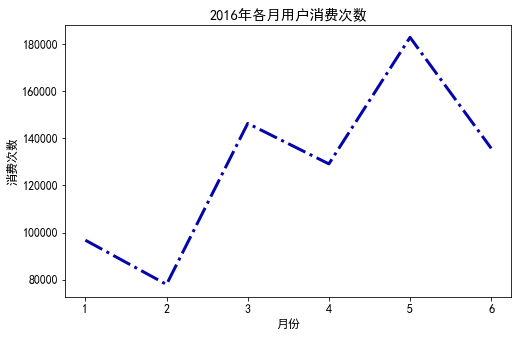

In [3]:
# 提取月份
data_month = data1['date'].apply(lambda x: x.month) 

# 对各月份用户消费次数进行统计
data_count = data_month.value_counts().sort_index(ascending=True)

# 绘制用户消费次数折线图
fig = plt.figure(figsize=(8, 5))  # 设置画布大小
plt.rcParams['font.sans-serif'] = 'SimHei'  # 设置中文显示
plt.rcParams['axes.unicode_minus'] = False
plt.rc('font', size=12)
plt.plot(data_count.index, data_count, color='#0504aa', linewidth=3.0, linestyle='-.')
plt.xlabel('月份')
plt.ylabel('消费次数')
plt.title('2016年各月用户消费次数')
plt.show()

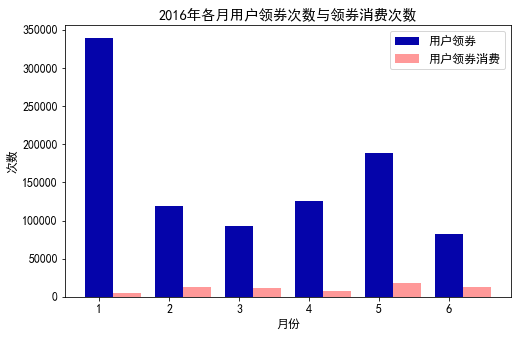

In [4]:
# 提取领券日期的月份
received_month = data1['date_received'].apply(lambda x: x.month)
month_count = received_month.value_counts().sort_index(ascending=True)

# 获取领券消费数据
cop_distance = data1.loc[data1['date'].notnull()&data1['coupon_id'].notnull(),['user_id', 'distance', 'date', 'discount_rate']]
# 统计领券消费次数
date_month = cop_distance['date'].apply(lambda x: x.month)
datemonth_count = date_month.value_counts().sort_index(ascending=True)
datemonth_countlist = list(datemonth_count)  # 转为列表

# 绘制用户领券次数与领券消费次数的柱形图
import numpy as np
fig = plt.figure(figsize=(8, 5))  # 设置画布大小
name_list = [i for i in range(1, 7)]; x = [i for i in range(1, 7)]
width = 0.4  # width设置宽度大小
plt.bar(x, height=list(month_count), width=width, label='用户领券', alpha=1, color='#0504aa')
for i in range(len(x)):
    x[i] = x[i] + width
plt.bar(x, height=np.array(datemonth_countlist), width=width, label='用户领券消费', alpha=0.4, color='red')
plt.legend() # 图例
plt.xlabel('月份')
plt.ylabel('次数')
plt.title('2016年各月用户领券次数与领券消费次数')
plt.show()

参与投放优惠券商户总数为： 5363
商户最多投放优惠券117818张
商户最少投放优惠券1张


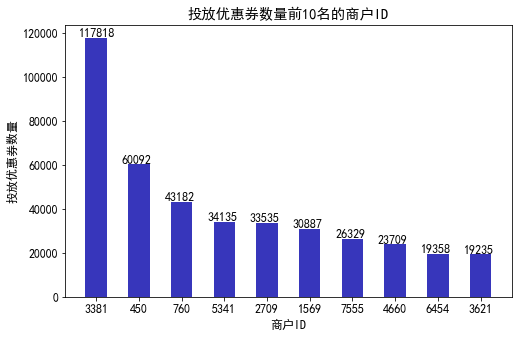

In [5]:
# 提取商户投放优惠券数据 
coupon_data = data1.loc[data1['coupon_id'].notnull(), ['merchant_id', 'coupon_id']]
merchant_count = coupon_data['merchant_id'].value_counts()
print('参与投放优惠券商户总数为：', merchant_count.shape[0])
print('商户最多投放优惠券{max_count}张\n商户最少投放优惠券{min_count}张'.format(max_count=merchant_count.max(), min_count=merchant_count.min()))

# 绘制柱形图分析商家投放数量
fig = plt.figure(figsize=(8, 5))  # 设置画布大小
plt.rc('font', size=12)
plt.bar(x=range(len(merchant_count[:10])), height=merchant_count[:10], width=0.5, alpha=0.8, color='#0504aa')
# 给柱形图添加数据标注
for x, y in enumerate(merchant_count[:10]):
    plt.text(x-0.4, y+500, "%s" %y)
plt.xticks(range(len(merchant_count[:10])), merchant_count[:10].index)
plt.xlabel('商户ID')
plt.ylabel('投放优惠券数量')
plt.title('投放优惠券数量前10名的商户ID')
plt.show()

数据形状: (768767, 3)


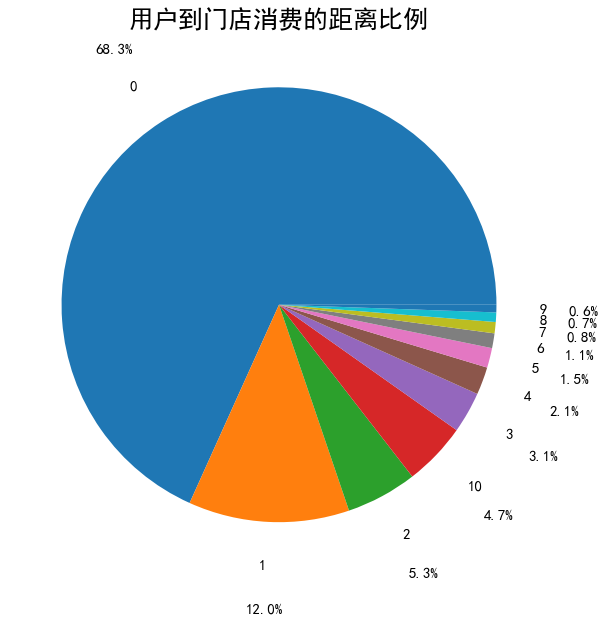

In [6]:
# 提取用户消费次数数据
date_distance = data1.loc[data1['date'].notnull() & data1['distance'].notnull(), ['user_id', 'distance', 'date']]
print('数据形状:', date_distance.shape)

# 统计用户消费次数
dis_count = date_distance['distance'].value_counts()

# 绘制用户到门店消费的距离比例饼图
fig = plt.figure(figsize=(10, 10))  # 设置画布大小
plt.rcParams['font.sans-serif'] = 'SimHei'  # 设置中文显示
plt.rcParams['axes.unicode_minus'] = False
plt.rc('font', size=15)
plt.pie(x=dis_count, labels=dis_count.index, labeldistance=1.2,pctdistance=1.4, autopct='%1.1f%%')
plt.title('用户到门店消费的距离比例', fontdict={'weight': 'normal','size': 25})
plt.show()

数据形状: (67165, 4)
数据形状: (701602, 4)


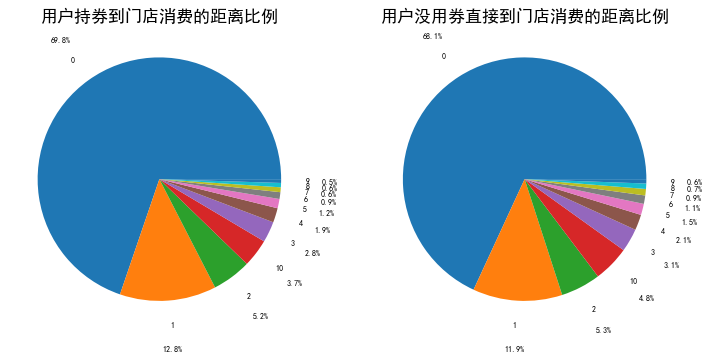

In [7]:
# 提取用户领券到店铺消费距离数据
cop_distance = data1.loc[data1['date'].notnull() & data1['distance'].notnull()&data1['coupon_id'].notnull(),
                         ['user_id', 'distance', 'date', 'discount_rate']]
print('数据形状:', cop_distance.shape) 
cop_count = cop_distance['distance'].value_counts()

# 提取用户未用券到店铺消费距离数据
nocop_distance = data1.loc[data1['date'].notnull() & data1['distance'].notnull()&data1['coupon_id'].isnull(),
                           ['user_id', 'distance', 'date', 'discount_rate']]
print('数据形状:', nocop_distance.shape)
nocop_count = nocop_distance['distance'].value_counts()

# 绘制用户持券到门店消费的距离比例饼图比例饼图
plt.figure(figsize=(12, 6))  # 设置画布大小
plt.subplot(1, 2, 1)  # 子图
plt.rcParams['font.sans-serif'] = 'SimHei'  # 设置中文显示
plt.rcParams['axes.unicode_minus'] = False
plt.pie(x=cop_count, labels=cop_count.index, pctdistance=1.4, labeldistance=1.2, textprops=dict(fontsize=8), autopct='%1.1f%%')
plt.title('用户持券到门店消费的距离比例', fontdict={'weight': 'normal','size': 17})

# 绘制用户未持券直接到门店消费的距离比例饼图
plt.subplot(1, 2, 2)
plt.pie(x=nocop_count, labels=nocop_count.index, pctdistance=1.4, labeldistance=1.2,textprops=dict(fontsize=8), autopct='%1.1f%%')
plt.title('用户没用券直接到门店消费的距离比例', fontdict={'weight':'normal','size': 17})
plt.savefig('../img/分析用户持券与未持券到门店消费的距离比例饼图.jpg', dpi=720)
plt.show()


## 数据预处理

In [8]:
import pandas as pd
import numpy as np
# 读取训练样本
data = pd.read_csv('../data/train.csv')

# 处理data_received属性并转为时间类型
data['date_received'] = data['date_received'].astype('str').apply(lambda x: x.split('.')[0])
data['date_received'] = pd.to_datetime(data['date_received'])

# 处理date属性并转为时间类型
data['date'] = data[ 'date'].astype('str').apply(lambda x: x.split('.')[0])
data['date'] = pd.to_datetime(data['date'])

# 自定义discount函数处理优惠率属性
data['discount_rate'] = data['discount_rate'].fillna('null')
def discount(x):
    if ':' in x :
        split = x.split(':')
        discount_rate = (int(split[0]) - int(split[1])) / int(split[0])
        return round(discount_rate, 2)
    elif x == 'null':
        return np.nan
    else :
        return float(x) 
# 调用discount函数将满减优惠改写成折扣率形式
data['discount_rate'] = data['discount_rate'].map(discount)

D:\DELL\AppData\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3063: DtypeWarning: Columns (3) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [9]:
# 标记样本
# 建立训练样本分类标签
# 创建label列值为0，假设所有样本均为负样本（未使用优惠券或领取优惠券15天内未使用），记为0
data["label"] = 0
# 优惠券ID为空（即未领取优惠券进行消费）的样本为普通样本，记为-1
data.loc[data['coupon_id'].isnull(), 'label'] = -1
# 领取优惠券在15天内使用的样本为正样本，记为1
data.loc[(data['date'] - data['date_received']).dt.days <= 15, 'label'] = 1

# 构建指标
quality = data.copy()
# 导入自定义特征包feature_name构建用户、商户、优惠券、交互相关指标
from feature_name import feature_name
data_user, data_merchant, data_coupon, data_mutual = feature_name(train_quality=quality)

# 对构建后的用户、商户、优惠券、交互相关指标进行数据拼接
# 对样本与指标类型表进行拼接
merge = pd.merge(data_user, quality, on='user_id')
merge = pd.merge(merge, data_merchant, on="merchant_id")
merge = pd.merge(merge, data_coupon, on='merchant_id')
clean_train = pd.merge(merge, data_mutual, on=['user_id', 'merchant_id'])
clean_train.isnull().sum()  # 统计缺失值
clean_train.fillna(0)  # 缺失值填充
print('构建指标后训练样本的形状：', clean_train.shape[0])

# 写出数据
clean_train.to_csv('../tmp/clean_train.csv', index=False)

构建指标后训练样本的形状： 1444037


In [10]:
import pandas as pd
import numpy as np
# 读取测试样本
data = pd.read_csv('../data/test.csv')

# 处理data_received属性并转为时间类型
data['date_received'] = data['date_received'].astype('str').apply(lambda x:x.split('.')[0])
data['date_received'] = pd.to_datetime(data['date_received'])

# 处理date属性并转为时间类型
data['date'] = data[ 'date'].astype('str').apply(lambda x:x.split('.')[0])
data['date'] = pd.to_datetime(data['date'])

# 自定义discount函数处理优惠率属性
data['discount_rate'] = data['discount_rate'].fillna('null')
def discount(x):
    if ':' in x :
        split = x.split(':')
        discount_rate = (int(split[0])-int(split[1]))/int(split[0])
        return round(discount_rate, 2)
    elif x == 'null':
        return np.nan
    else :
        return float(x) 
# 调用discount函数将满减优惠改写成折扣率形式
data['discount_rate'] = data['discount_rate'].map(discount)

In [11]:
# 标记样本
# 建立训练样本分类标签,-1代表普通样本，1代表正样本， 0代表负样本
data["label"] = 0  # 创建一个列值为0，
data.loc[data['coupon_id'].isnull(), 'label']=-1  #普通样本-1
data.loc[(data['date']-data['date_received']).dt.days<=15, 'label']=1  # 正样本1

# 构建指标
quality = data.copy()
# 导入自定义特征包feature_name构建用户、商户、优惠券、交互相关指标
from feature_name import feature_name
data_user, data_merchant, data_coupon, data_mutual = feature_name(train_quality=quality)

# 对构建后的用户、商户、优惠券、交互相关指标进行数据拼接
# 对样本与指标类型表进行拼接
merge = pd.merge(data_user, quality, on='user_id')
merge = pd.merge(merge, data_merchant, on="merchant_id")
merge = pd.merge(merge, data_coupon, on='merchant_id')
clean_test = pd.merge(merge, data_mutual, on=['user_id','merchant_id'])
clean_test.isnull().sum()  # 统计缺失值
clean_test.fillna(0)  # 缺失值填充
print('构建指标后测试样本的形状：', clean_test.shape[0])

# 写出数据
clean_test.to_csv('../tmp/clean_test.csv', index=False)

构建指标后测试样本的形状： 204844


## 分析与建模

In [13]:
import pandas as pd
import numpy as np
# 读取数据
train = pd.read_csv('../tmp/clean_train.csv')
test = pd.read_csv('../tmp/clean_test.csv')
# 抽取正负样本
train = train[train['label'] == 1].sample(sum(train['label'] == 1)).append(train[train['label'] == 0].sample(sum(train['label'] == 0)))
test = test[test['label'] == 1].sample(sum(test['label'] == 1)).append(test[test['label'] == 0].sample(sum(test['label'] == 0)))
# 删除列
x_train = train.drop(['user_id', 'merchant_id', 'coupon_id', 'date_received', 'date'], axis=1)
x_test = test.drop(['user_id', 'merchant_id', 'coupon_id', 'date_received', 'date', 'label'], axis=1)
# 处理无穷数据（无穷数据大或者无穷数据小）
x_train[np.isinf(x_train)] = 0
x_test[np.isinf(x_test)] = 0

In [14]:
# 决策树分类模型
from sklearn.tree import DecisionTreeClassifier
model_dt1 = DecisionTreeClassifier(max_leaf_nodes=16, random_state=123).fit(x_train.drop(['label'], axis=1), x_train['label'])
# 模型预测
pre_dt = model_dt1.predict(x_test)
# dt_class存放决策树分类预测结果
dt_class = test[['user_id', 'merchant_id', 'coupon_id']]
dt_class['class'] = pre_dt
# 写出决策树分类预测结果
dt_class.to_csv('../tmp/dt_class.csv', index=False)

D:\DELL\AppData\anaconda3\lib\site-packages\ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [15]:
# 梯度提升分类模型
from sklearn.ensemble import GradientBoostingClassifier
# 构建模型
model = GradientBoostingClassifier(n_estimators=100, max_depth=5)
# 模型训练
model.fit(x_train.drop(['label'], axis=1), x_train['label'])
# 模型预测
pre_gb = model.predict(x_test)
# gb_class存放梯度提升预测结果
gb_class = test[['user_id', 'merchant_id', 'coupon_id']]
gb_class['class'] = pre_gb
# 写出梯度提升预测结果
gb_class.to_csv('../tmp/gb_class.csv', index=False)

D:\DELL\AppData\anaconda3\lib\site-packages\ipykernel_launcher.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # This is added back by InteractiveShellApp.init_path()


In [18]:
!pip install -i https://pypi.tuna.tsinghua.edu.cn/simple xgboost

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [19]:
#!pip install xgboost
# XGBoost分类模型
import xgboost as xgb
model_test = xgb.XGBClassifier(max_depth=6, learning_rate=0.1, n_estimators=150, silent=True, objective='binary:logistic')
# max_depth是数的最大深度，默认值为6，避免过拟合
# learning_rate为学习率，n_estimators为总共迭代的次数，即决策树的个数，silent为中间过程
# binary:logistic 二分类的逻辑回归，返回预测的概率(不是类别)
# 模型训练
model_test.fit(x_train.drop(['label'], axis=1), x_train['label'])
# 模型预测
y_pred = model_test.predict(x_test)
# xgb_class存放xgboost预测结果
xgb_class = test[['user_id', 'merchant_id', 'coupon_id']]
xgb_class['class'] = y_pred
# 写出xgboost预测结果
xgb_class.to_csv('../tmp/xgb_class.csv', index=False)

[22:46:57] WARNING: C:/Users/administrator/workspace/xgboost-win64_release_1.6.0/src/learner.cc:627: 
Parameters: { "silent" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.




D:\DELL\AppData\anaconda3\lib\site-packages\ipykernel_launcher.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


## 模型评价

In [21]:
from sklearn.metrics import precision_score, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt

train_class = pd.read_csv('../tmp/clean_train.csv')  # 已预处理和贴标签训练数据
test_class = pd.read_csv('../tmp/clean_test.csv')  # 已预处理和贴标签测试数据
# 抽取正负样本
train_class = train_class[train_class['label'] == 1].sample(sum(
    train_class['label'] == 1)).append(train_class[train_class['label'] == 0].sample(sum(train_class['label'] == 0)))
test_class = test_class[test_class['label'] == 1].sample(sum(
    test_class['label'] == 1)).append(test_class[test_class['label'] == 0].sample(sum(test_class['label'] == 0)))
# 删除列
x_train = train_class.drop(['user_id', 'merchant_id', 'coupon_id', 'date_received', 'date'], axis=1)
x_test = test_class.drop(['user_id', 'merchant_id', 'coupon_id', 'date_received', 'date'], axis=1)
# 处理无穷数据(无穷数据大或者无穷数据小)
x_train[np.isinf(x_train)] = 0
x_test[np.isinf(x_test)] = 0

AUC值为99.82%:
准确率为98.63%:
精确率为94.20%


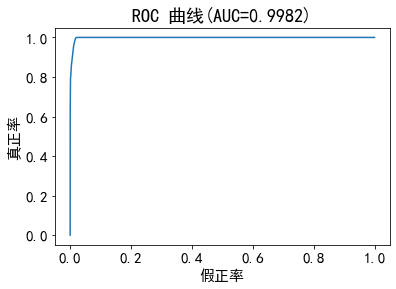

In [22]:
# 决策树分类模型
model_dt_evaluate = DecisionTreeClassifier(max_leaf_nodes=16, random_state=123).fit(x_train.drop(['label'], axis=1), x_train['label'])
model_dt_pre = model_dt_evaluate.predict(x_test.drop(['label'], axis=1))  # 模型预测

# 决策树分类模型评价指标值
pre = model_dt_evaluate.predict_proba(x_test.drop(['label'], axis=1))  # 输出预测概率
auc = roc_auc_score(x_test['label'], pre[:, 1])  # 计算AUC值
print('AUC值为%.2f%%:'% (auc * 100.0))
dt_evaluate_accuracy = accuracy_score(x_test['label'], model_dt_pre)
print('准确率为%.2f%%:'% (dt_evaluate_accuracy * 100.0))
dt_evaluate_p = precision_score(x_test['label'], model_dt_pre)
print('精确率为%.2f%%'% (dt_evaluate_p * 100.0))
# 绘制ROC曲线
tr_fpr, tr_tpr, tr_threasholds = roc_curve(x_test['label'], pre[:, 1])
plt.title("ROC %s(AUC=%.4f)"% ('曲线', auc))
plt.xlabel('假正率')
plt.ylabel('真正率')
plt.plot(tr_fpr, tr_tpr)
plt.show()

AUC值为99.85%:
准确率为98.69%:
精确率为92.20%


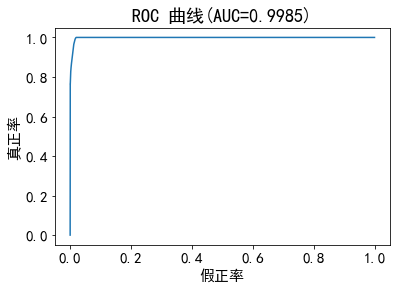

In [23]:
# 梯度提升分类
model = GradientBoostingClassifier(n_estimators=100, max_depth=5)
model.fit(x_train.drop(['label'], axis=1), x_train['label'])  # 模型训练
# 梯度提升评价指标
pre = model.predict_proba(x_test.drop(['label'], axis=1))  # 输出预测概率
auc = roc_auc_score(x_test['label'], pre[:, 1])  # 计算AUC值
print('AUC值为%.2f%%:'% (auc * 100.0))
pre1 = model.predict(x_test.drop(['label'], axis=1))
gb_evaluate_accuracy = accuracy_score(x_test['label'], pre1)
print('准确率为%.2f%%:'% (gb_evaluate_accuracy * 100.0))
gb_evaluate_p = precision_score(x_test['label'], pre1)
print('精确率为%.2f%%'% (gb_evaluate_p * 100.0))
# 绘制ROC曲线
tr_fpr, tr_tpr, tr_threasholds = roc_curve(x_test['label'], pre[:, 1])
plt.title("ROC %s(AUC=%.4f)"% ('曲线', auc))
plt.xlabel('假正率')
plt.ylabel('真正率')
plt.plot(tr_fpr, tr_tpr)
plt.show()

[22:54:46] WARNING: C:/Users/administrator/workspace/xgboost-win64_release_1.6.0/src/learner.cc:627: 
Parameters: { "silent" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


AUC值为99.85%:
准确率为:98.68%
精确率为:92.18%


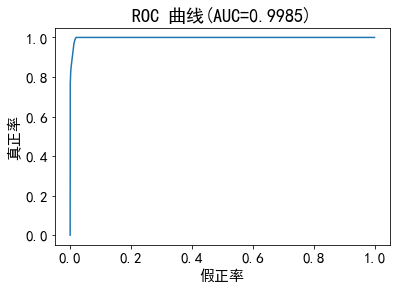

In [24]:
# XGBoost分类模型
model_xgb_evaluate = xgb.XGBClassifier(max_depth=6, learning_rate=0.1,n_estimators=150, silent=True, objective='binary:logistic')
model_xgb_evaluate.fit(x_train.drop(['label'], axis=1), x_train['label'])

# 对验证样本进行预测
model_xgb_pre = model_xgb_evaluate.predict(x_test.drop(['label'], axis=1))

# XGBoost分类模型评价指标
pre = model_xgb_evaluate.predict_proba(x_test.drop(['label'], axis=1))  # 输出预测概率
auc = roc_auc_score(x_test['label'], pre[:, 1])  # 计算AUC值
print('AUC值为%.2f%%:'% (auc * 100.0))
xfb_evaluate_accuracy = accuracy_score(x_test['label'], model_xgb_pre)
print('准确率为:%.2f%%'% (xfb_evaluate_accuracy * 100.0))
xfb_evaluate_p = precision_score(x_test['label'], model_xgb_pre)
print('精确率为:%.2f%%'% (xfb_evaluate_p * 100.0))
# 绘制ROC曲线
tr_fpr, tr_tpr, tr_threasholds = roc_curve(x_test['label'], pre[:, 1])
plt.title("ROC %s(AUC=%.4f)"% ('曲线', auc))
plt.xlabel('假正率')
plt.ylabel('真正率')
plt.plot(tr_fpr, tr_tpr)
plt.show()